In [2]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns
sns.set_theme()

In [3]:
df_final = pd.read_csv('../data_processed/df_final_1.csv')

In [4]:
df_ht = df_final.copy()

In [ ]:
median_density = df_ht['Densità_della_popolazione'].median()

df_ht['Density Group'] = np.where(
    df_ht['Densità_della_popolazione'] > median_density,
    'High Population Density',
    'Low Population Density'
)

df_ht = df_ht[['Density Group', 'Road_accident_per_Kmq']].dropna()

In [7]:
df_ht.head(5)

,Density Group,Road_accident_per_Kmq
0,High Population Density,0.380338
1,High Population Density,0.380338
2,High Population Density,0.304270
3,High Population Density,0.684608
4,High Population Density,0.152135


Hypothesis test

Do municipalities with high accident density have a different road accident rate per kmq compared to municipalities with low accident density?

H0 : The average road accident rate per kmq is the same in municipalities with high accident density and in municipalities with low accident density

H1 : The average road accident rate per kmq is different between municipalities with high accident density and municipalities with low accident density.

Observed difference statistic: 1.2629


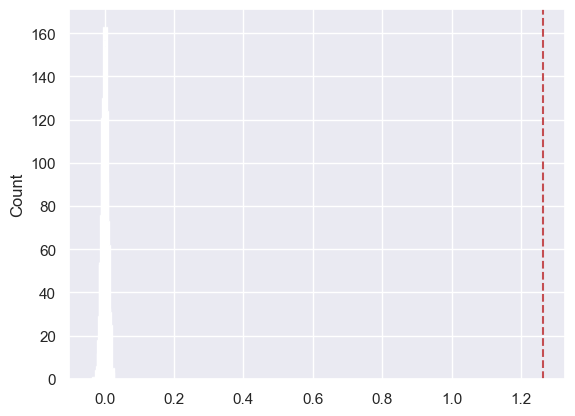

Values more extreme than observed: 0
p-value: 0.0
H0 rejected | the observed result is statistically significant | p-value <= alpha


In [8]:
def abtest(df, exp_groups, exp_metric, n_rounds=2000, alpha=0.05): 

    a, b = df[exp_groups].unique()
    mu_a = np.mean(df[df[exp_groups]==a][exp_metric])
    mu_b = np.mean(df[df[exp_groups]==b][exp_metric])
    ab_mu_diff = mu_a - mu_b
    print('Observed difference statistic:', round(ab_mu_diff, 4))
    
    np.random.seed(1)
    mu_diff_samples = []
    for i in range(n_rounds): 
        # extract a subsample of 50% of data without replacement
        df_sample1 = df.sample(frac=0.5, replace=False)
        # use set() to get indexes of rows that were not extracted from df in previous step
        ix2 = set(df.index) - set(df_sample1.index)
        # create dataframe with other 50% of data
        df_sample2 = df.iloc[list(ix2)]
        # calculate difference in mean from each sample
        mu_diff_temp = np.mean(df_sample1[exp_metric]) - np.mean(df_sample2[exp_metric])
        # append sampled mean difference to mu_diff_samples list
        mu_diff_samples.append(mu_diff_temp)
    
    sns.histplot(mu_diff_samples)
    plt.axvline(ab_mu_diff, 0, 1, color='r', linestyle='--')
    plt.show()
    
    print('Values more extreme than observed:', sum([el >= ab_mu_diff for el in mu_diff_samples]))
    p_value = sum([el > ab_mu_diff for el in mu_diff_samples])/n_rounds
    print('p-value:', p_value)
    
    if p_value <= alpha: 
        print('H0 rejected | the observed result is statistically significant | p-value <= alpha')
    else: 
        print('H0 accepted | the observed result is not statistically significant | p-value > alpha')
        
    #return {'samples': mu_diff_samples, 'pvalue': p_value}

abtest(
    df_ht,
    'Density Group',
    'Road_accident_per_Kmq',
    n_rounds=2000,
    alpha=0.05
)

HYPOTHESIS TEST INTERPRETATION

The histogram shows the distribution of the simulated test statistics, while the red dashed line represents the observed difference between the two groups (1.3481). The p-value is close to zero, providing strong statistical evidence against the null hypothesis. Therefore, the null hypothesis is rejected and we conclude that the average road accident rate per Kmq differs significantly between municipalites with high accident density and those with low accident density